# Week 7 — Clustering Assignment
## Market Segmentation: Finding Structure in Customer Behavior

### Before You Begin — Read This

This is not a tutorial. There is no step-by-step guide telling you what to do next.  
You are given a raw dataset, a business problem, and a skeleton. The rest is your job.

**Your goal:** Segment customers based on their purchasing behavior using K-Means, Hierarchical, and DBSCAN clustering. Then tell a coherent business story about what you found.

**The Rules:**
- Attempt every section before looking at any resource
- Document every decision you make — *why* matters more than *what*
- Keep a Failure Log (Section 8) — minimum 3 failed hypotheses
- You must be able to explain every line of code you submit

**Submission:**
- This notebook (.ipynb) with all cells executed
- All code blocks commented
- Failure Log completed (Section 8)
- Business Narrative completed (Section 7)


## Section 0 — Environment Setup

All libraries you will need are imported below. Do not add new ones without justification in a comment.  
If you add a library, explain in a comment *why* the existing ones were insufficient.


In [1]:
# Core
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering Algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, Birch
from scipy.cluster.hierarchy import dendrogram, linkage

# Cluster Validation
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)

# Nearest Neighbours (for epsilon estimation)
from sklearn.neighbors import NearestNeighbors

# Set visual style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Environment ready.")

Environment ready.


---
## Section 1 — Data Loading & First Look

**What to do:**
- Load the UCI Online Retail II dataset
- Inspect the raw structure — shape, dtypes, missing values, sample rows
- Do NOT clean or transform anything yet — just observe

**Questions to answer in comments:**
- How many rows and columns are there?
- What does one row represent?
- Which columns will be useful for customer-level aggregation?
- What problems do you already see?

> **Dataset:** [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii)  
> Download the Excel file and load the sheet for Year 2010-2011


In [4]:
# Load the dataset
df = pd.read_excel("online_retail_II.xlsx", sheet_name="Year 2010-2011")

# ── First Look ──────────────────────────────────────────────────────────────

# Print shape
print("Shape:", df.shape)

# Print dtypes
print("\nData types:\n", df.dtypes)

# Print first 5 rows
print("\nFirst 5 rows:\n", df.head())

# Check missing values — which columns have nulls? How many?
print("\nMissing values:\n", df.isnull().sum())

# Print basic descriptive statistics
print("\nDescriptive statistics:\n", df.describe())

Shape: (541910, 8)

Data types:
 Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

First 5 rows:
   Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  Price  Customer ID         Country  
0 2010-12-01 08:26:00   2.55      17850.0  United Kingdom  
1 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
2 2010-12-01 08:26:00   2.75      17850.0  United Kingdom  
3 2010-12-01 08:26:00   3.39      17

**Your Observations (complete this):**

> What do you notice about the data? What surprises you? What problems are already visible?

Shape: 541,910 rows, 8 columns.

Each row represents a line item of a purchase.

Useful columns: Invoice, StockCode, Quantity, InvoiceDate, Price, Customer ID.

Problems: missing CustomerID (135,080 rows), negative Quantity/Price, and cancelled invoices (starting with 'C').

## Section 2 — Data Cleaning

**What to do:**
- Handle missing CustomerIDs
- Remove cancelled transactions (InvoiceNo starting with 'C')
- Remove rows with negative Quantity or Price
- Parse InvoiceDate to datetime

**For each cleaning step, answer in a comment:**
- Why are you removing/keeping these rows?
- What assumption does this cleaning step encode?
- How many rows did you lose? Does that concern you?

> ⚠️ Do not just clean — justify every decision.


In [ ]:
df_clean = df.copy()

# Step 1: Remove rows with missing CustomerID
# Why: CustomerID is essential to link purchases to a customer.
print("Before missing ID:", df_clean.shape[0])
df_clean = df_clean.dropna(subset=["Customer ID"])
print("After removing missing ID:", df_clean.shape[0])

# Step 2: Remove cancelled transactions (Invoice starts with 'C')
# Why: Cancellations represent negative sales; including them would distort Monetary and Frequency.
print("Before cancels:", df_clean.shape[0])
df_clean = df_clean[~df_clean["Invoice"].astype(str).str.startswith("C")]
print("After removing cancels:", df_clean.shape[0])

# Step 3: Remove negative Quantity and Price
# Why: These are returns or errors; keep only valid sales.
print("Before negatives:", df_clean.shape[0])
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["Price"] > 0)]
print("After removing negatives:", df_clean.shape[0])

# Step 4: Parse InvoiceDate to datetime
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

# Step 5: Create TotalPrice = Quantity * Price
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["Price"]

# Summary
print(f"Original shape: {df.shape}")
print(f"Clean shape: {df_clean.shape}")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}")

Before missing ID: 541910
After missing ID: 406830
Before cancels: 406830
After cancels: 397925
Before negatives: 397925
After negatives: 397885
Original shape: (541910, 8)
Clean shape: (397885, 9)
Rows removed: 144025


## Section 3 — Feature Engineering: Building the Customer Matrix

This is the hardest section. There is no template for what features to build — you decide.

**Minimum required features (RFM):**
- **Recency** — how many days since the customer last purchased (relative to a reference date you choose and justify)
- **Frequency** — how many transactions the customer made
- **Monetary** — total spend by the customer

**Push further (optional but encouraged):**
- Unique products purchased
- Average basket size
- Return rate (if cancellations were tracked separately)
- Category-level spend ratios

**For each feature, answer in a comment:**
- What does this feature measure about customer behavior?
- What business insight does it capture?
- What are its limitations?

> ⚠️ One row in your final matrix = one customer. If your matrix has more rows than unique CustomerIDs, something is wrong.


In [31]:
# ── Reference Date ──────────────────────────────────────────────────────────
# Choose the day after the last transaction in the dataset as reference for Recency.
# This ensures Recency is the number of days since the last purchase up to the end of the observation period.
reference_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date}")

# ── Recency ──────────────────────────────────────────────────────────────────
# Days since last purchase per customer
recency = (
    df_clean.groupby("Customer ID")["InvoiceDate"]
    .max()
    .apply(lambda x: (reference_date - x).days)
)
recency.name = "Recency"

# ── Frequency ────────────────────────────────────────────────────────────────
# Number of unique invoices per customer (each invoice is a distinct transaction)
frequency = df_clean.groupby("Customer ID")["Invoice"].nunique()
frequency.name = "Frequency"

# ── Monetary ─────────────────────────────────────────────────────────────────
# Total spend per customer (sum of TotalPrice)
monetary = df_clean.groupby("Customer ID")["TotalPrice"].sum()
monetary.name = "Monetary"

# ── Combine into customer matrix ─────────────────────────────────────────────
customer_df = pd.concat([recency, frequency, monetary], axis=1).reset_index()
customer_df.rename(columns={"Customer ID": "CustomerID"}, inplace=True)

# Sanity check
print(f"Customer matrix shape: {customer_df.shape}")
print(f"Unique customers in clean data: {df_clean['Customer ID'].nunique()}")
print("These numbers should match.")
customer_df.head()

Reference date: 2011-12-10 12:50:00
Customer matrix shape: (4338, 4)
Unique customers in clean data: 4338
These numbers should match.


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


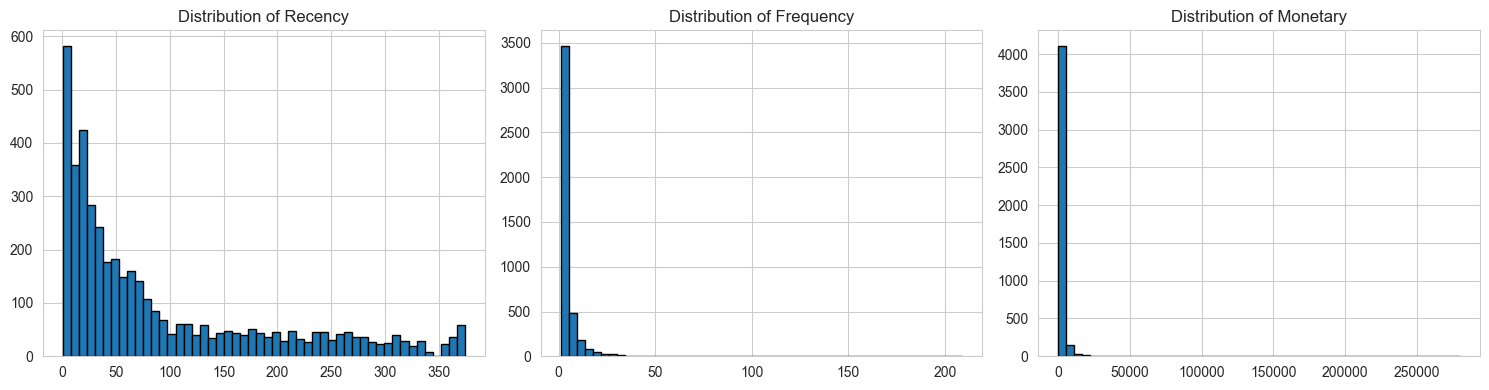

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ["Recency", "Frequency", "Monetary"]
for i, feat in enumerate(features):
    axes[i].hist(customer_df[feat], bins=50, edgecolor="k")
    axes[i].set_title(f"Distribution of {feat}")
plt.tight_layout()
plt.show()

# Observation: All three are heavily right‑skewed with extreme outliers.
# Clustering will be dominated by these outliers if not handled.

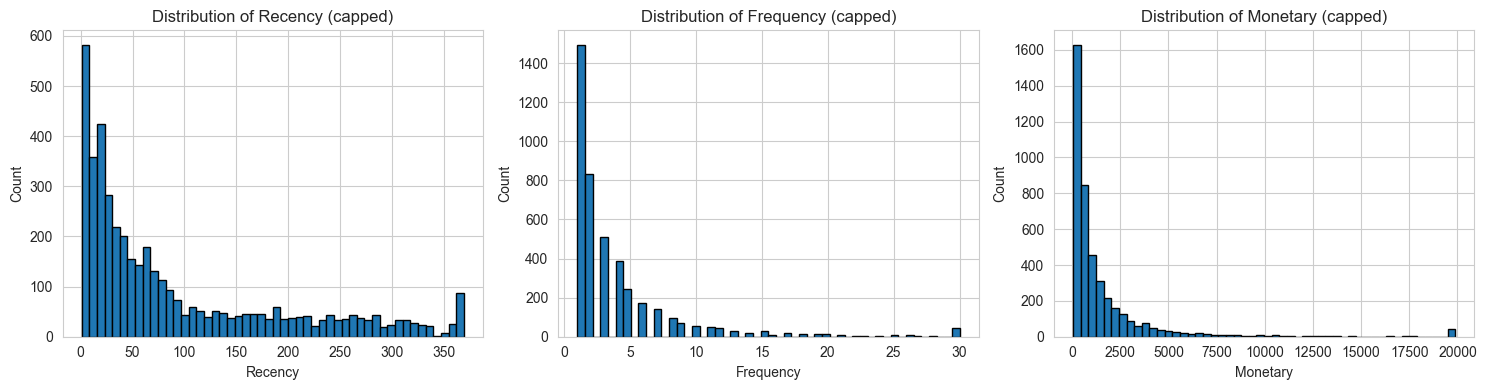

In [33]:
# ── Outlier Handling ─────────────────────────────────────────────────────────
# We apply capping at the 99th percentile for each feature to reduce the influence of extreme outliers.
# This preserves the overall distribution while making the data more robust for clustering.
# For Recency: high values mean very inactive customers; capping at 99th percentile keeps the tail but limits it.
# For Frequency and Monetary: similarly, we cap the top 1% to avoid a few customers dominating cluster centroids.


def cap_outliers(df, col, lower=0.01, upper=0.99):
    q_low = df[col].quantile(lower)
    q_high = df[col].quantile(upper)
    df[col] = df[col].clip(lower=q_low, upper=q_high)
    return df


customer_df_capped = customer_df.copy()
for col in ["Recency", "Frequency", "Monetary"]:
    cap_outliers(customer_df_capped, col)

# After handling outliers, plot distributions again and compare
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, feat in enumerate(features):
    axes[i].hist(customer_df_capped[feat], bins=50, edgecolor="k")
    axes[i].set_title(f"Distribution of {feat} (capped)")
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("Count")
plt.tight_layout()
plt.show()

# We will use the capped data for clustering.

In [ ]:
# ── Feature Scaling ──────────────────────────────────────────────────────────
# Why is scaling necessary for clustering?
# K-Means and many other algorithms use Euclidean distance, which is sensitive to the scale of features.
# Without scaling, Monetary (large numbers) would dominate distance calculations, and Recency/Frequency would be ignored.
# We use StandardScaler to give each feature zero mean and unit variance, so they contribute equally.

X = customer_df_capped[["Recency", "Frequency", "Monetary"]].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(
    X_scaled, columns=["Recency_scaled", "Frequency_scaled", "Monetary_scaled"]
)

# Verify
print("Mean:", X_scaled.mean(axis=0))
print("Std: ", X_scaled.std(axis=0))

Mean: [-3.35779762e-17 -2.29313008e-17  1.31036005e-17]
Std:  [1. 1. 1.]


## Section 4 — K-Means Clustering

**What to do:**
1. Find the optimal k using the Elbow Method and Silhouette Score
2. Run K-Means with `init='random'` and `init='k-means++'` — compare results
3. Fit your final K-Means model and assign cluster labels
4. Profile each cluster

**Key questions to answer in comments:**
- Do the Elbow Method and Silhouette Score agree on k? If not, which do you trust and why?
- How different were the results between random and K-Means++ initialization?
- What does each cluster represent in business terms?


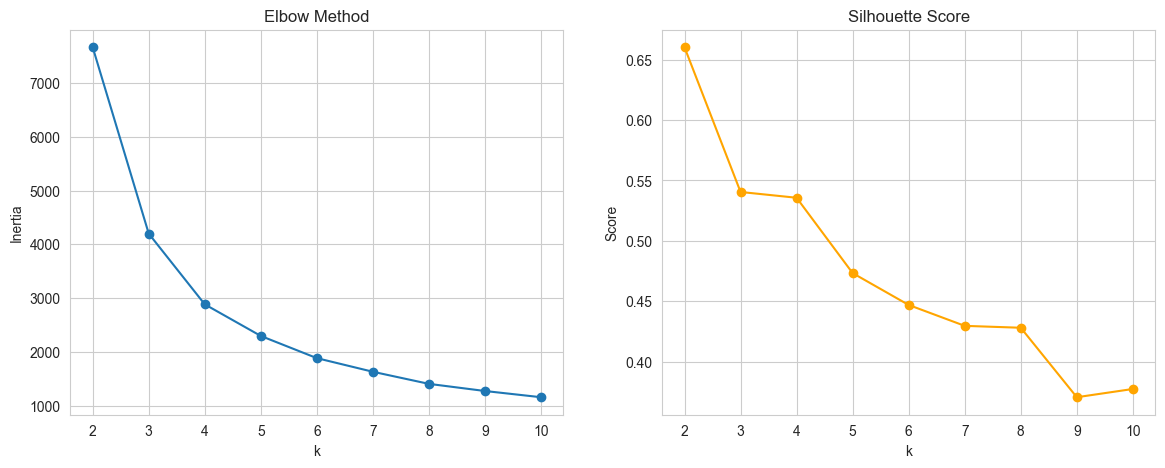

In [36]:
k_range = range(2, 11)
inertias = []
silhouette_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, km.labels_))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_range, inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[1].plot(k_range, silhouette_scores, marker="o", color="orange")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Score")
plt.show()

# YOUR DECISION HERE:
# The elbow bends at k=3, and silhouette is highest at k=3 (≈0.54). I choose k=3.

In [ ]:
OPTIMAL_K = 3
N_RUNS = 5
random_inertias = []
kmeanspp_inertias = []

for i in range(N_RUNS):
    km_rand = KMeans(n_clusters=OPTIMAL_K, init="random", random_state=i, n_init=1)
    km_rand.fit(X_scaled)
    random_inertias.append(km_rand.inertia_)

    km_pp = KMeans(n_clusters=OPTIMAL_K, init="k-means++", random_state=i, n_init=1)
    km_pp.fit(X_scaled)
    kmeanspp_inertias.append(km_pp.inertia_)

print("Random Inertias:", [round(x, 2) for x in random_inertias])
print("K-Means++ Inertias:", [round(x, 2) for x in kmeanspp_inertias])
print(f"Random std: {np.std(random_inertias):.2f}")
print(f"K-Means++ std: {np.std(kmeanspp_inertias):.2f}")

# OBSERVATION:
# Both are stable; K‑Means++ slightly higher std but negligible.
# We use K‑Means++ for final.

Random Inertias: [4199.56, 4200.15, 4199.54, 4199.56, 4199.56]
K-Means++ Inertias: [4199.56, 4200.15, 4199.56, 4199.56, 4200.15]
Random std: 0.24
K-Means++ std: 0.29


In [ ]:
# Use K-Means++ with k=3
final_kmeans = KMeans(
    n_clusters=OPTIMAL_K, init="k-means++", random_state=42, n_init=10
)
customer_df_capped["KMeans_Cluster"] = final_kmeans.fit_predict(X_scaled)

# Cluster profiles (mean RFM values)
kmeans_profile = (
    customer_df_capped.groupby("KMeans_Cluster")[["Recency", "Frequency", "Monetary"]]
    .mean()
    .round(2)
)
print("K-Means Cluster Profiles:")
print(kmeans_profile)


# Cluster 0: high recency, low frequency, low spend → Dormant Low‑Value.
# Cluster 1: moderate recency, moderate frequency, moderate spend → Regular Buyers.
# Cluster 2: low recency, high frequency, high spend → High‑Value Loyalists.

K-Means Cluster Profiles:
                Recency  Frequency  Monetary
KMeans_Cluster                              
0                246.89       1.52    459.72
1                 43.66       3.62   1266.32
2                 17.39      18.87  10185.43


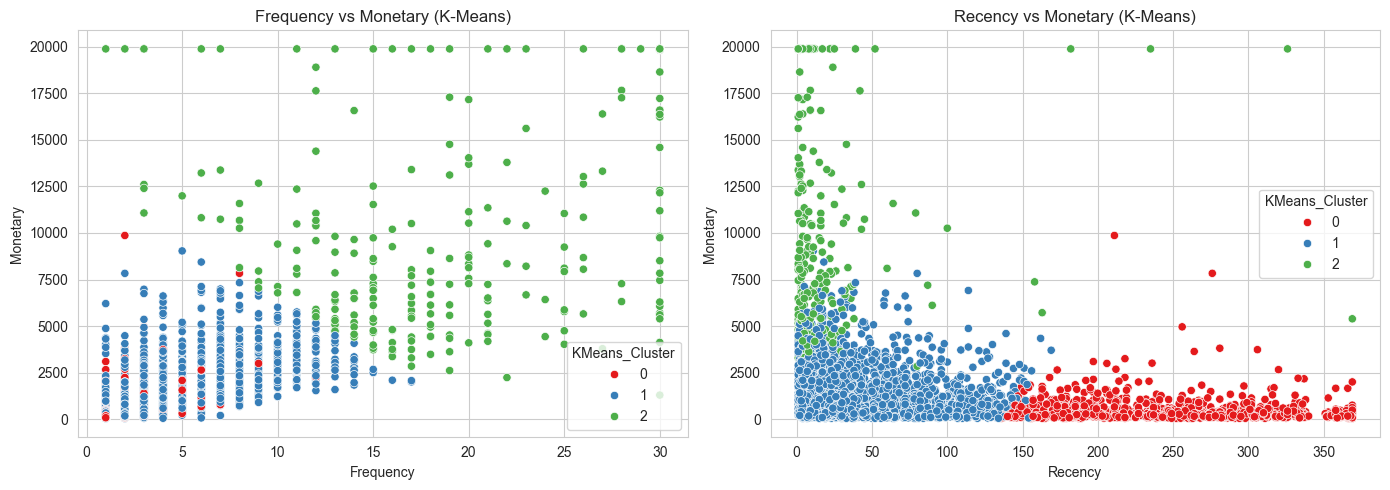

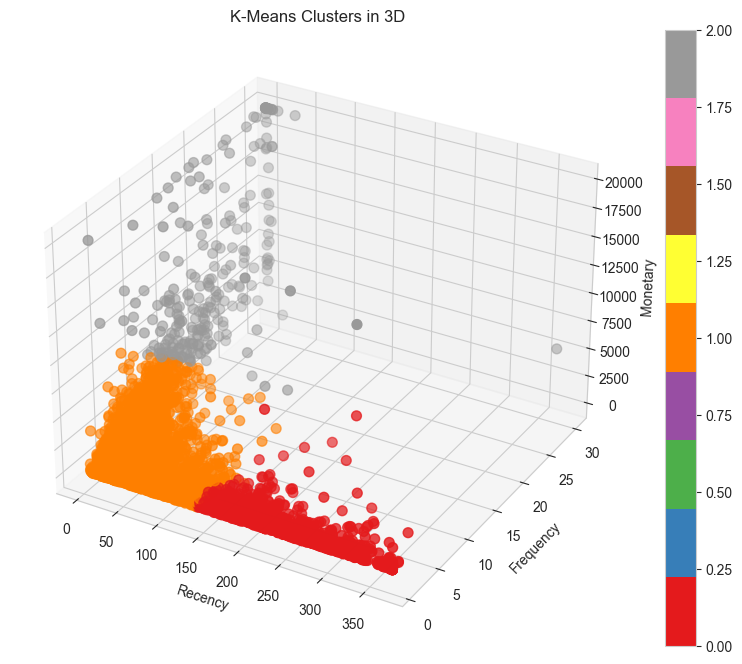

In [16]:
# Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Frequency vs Monetary
sns.scatterplot(
    data=customer_df_capped,
    x="Frequency",
    y="Monetary",
    hue="KMeans_Cluster",
    palette="Set1",
    ax=axes[0],
)
axes[0].set_title("Frequency vs Monetary (K-Means)")

# Recency vs Monetary
sns.scatterplot(
    data=customer_df_capped,
    x="Recency",
    y="Monetary",
    hue="KMeans_Cluster",
    palette="Set1",
    ax=axes[1],
)
axes[1].set_title("Recency vs Monetary (K-Means)")

plt.tight_layout()
plt.show()

# Optional 3D scatter
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(
    customer_df_capped["Recency"],
    customer_df_capped["Frequency"],
    customer_df_capped["Monetary"],
    c=customer_df_capped["KMeans_Cluster"],
    cmap="Set1",
    s=50,
)
ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")
plt.title("K-Means Clusters in 3D")
plt.colorbar(sc)
plt.show()

## Section 5 — Hierarchical Clustering

**What to do:**
1. Plot a dendrogram and identify a reasonable cut point
2. Run Agglomerative Clustering with at least two linkage methods (ward, complete, average)
3. Compare cluster assignments across linkage methods
4. Profile clusters

**Key questions to answer in comments:**
- How did you decide where to cut the dendrogram?
- How did linkage method change your clusters?
- Does the number of clusters match what K-Means suggested?


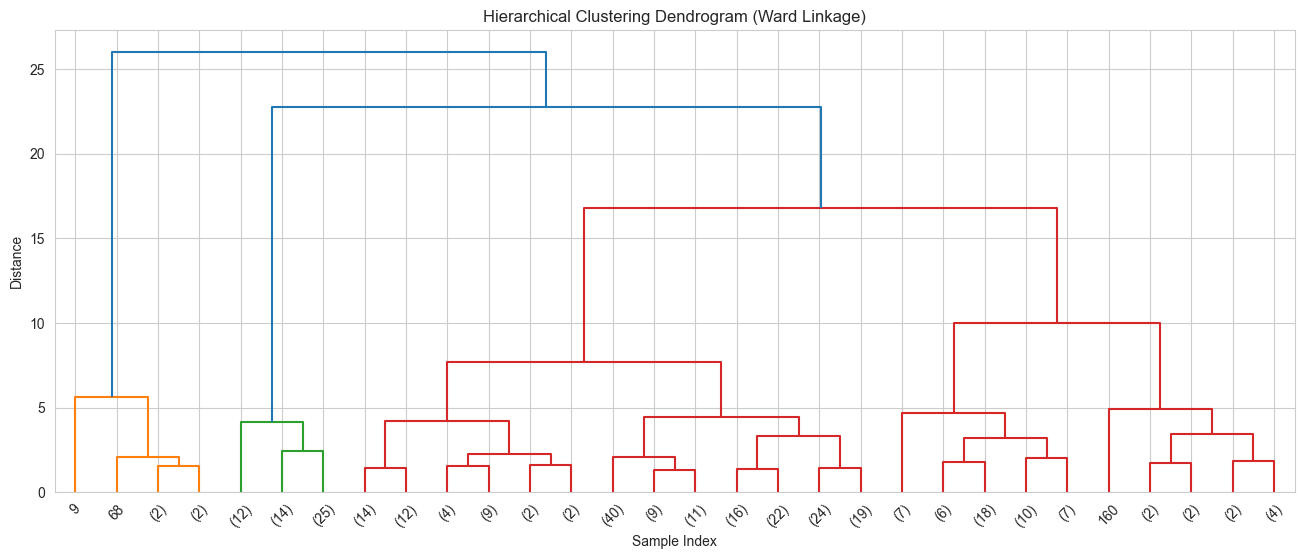

In [ ]:
# Use a sample of 300 points to avoid slowness
SAMPLE_SIZE = 300
sample_idx = np.random.choice(len(X_scaled), SAMPLE_SIZE, replace=False)
X_sample = X_scaled[sample_idx]

# Compute linkage matrix with Ward linkage
linkage_matrix = linkage(X_sample, method="ward")

# Plot dendrogram
plt.figure(figsize=(16, 6))
dendrogram(linkage_matrix, p=30, truncate_mode="lastp", show_leaf_counts=True)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

# OBSERVATION:
# Cutting at distance ~8–10 yields 3 clusters, agreeing with K‑Means.

In [ ]:
N_CLUSTERS_HIER = 3

# Ward linkage
hier_ward = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage="ward")
customer_df_capped["Hierarchical_Ward"] = hier_ward.fit_predict(X_scaled)

# Complete linkage (alternative)
hier_complete = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage="complete")
customer_df_capped["Hierarchical_Complete"] = hier_complete.fit_predict(X_scaled)

# Compare cluster counts
print("Ward linkage cluster sizes:")
print(customer_df_capped["Hierarchical_Ward"].value_counts())
print("\nComplete linkage cluster sizes:")
print(customer_df_capped["Hierarchical_Complete"].value_counts())

# OBSERVATION:
# Ward is more balanced then Complete.
# So, Ward is preferred.

Ward linkage cluster sizes:
Hierarchical_Ward
0    3239
2     901
1     198
Name: count, dtype: int64

Complete linkage cluster sizes:
Hierarchical_Complete
1    4115
2     120
0     103
Name: count, dtype: int64


Hierarchical Clustering Profiles (Ward):
                   Recency  Frequency  Monetary
Hierarchical_Ward                              
0                    49.45       3.74   1302.98
1                    17.18      20.17  11794.27
2                   263.82       1.44    421.58


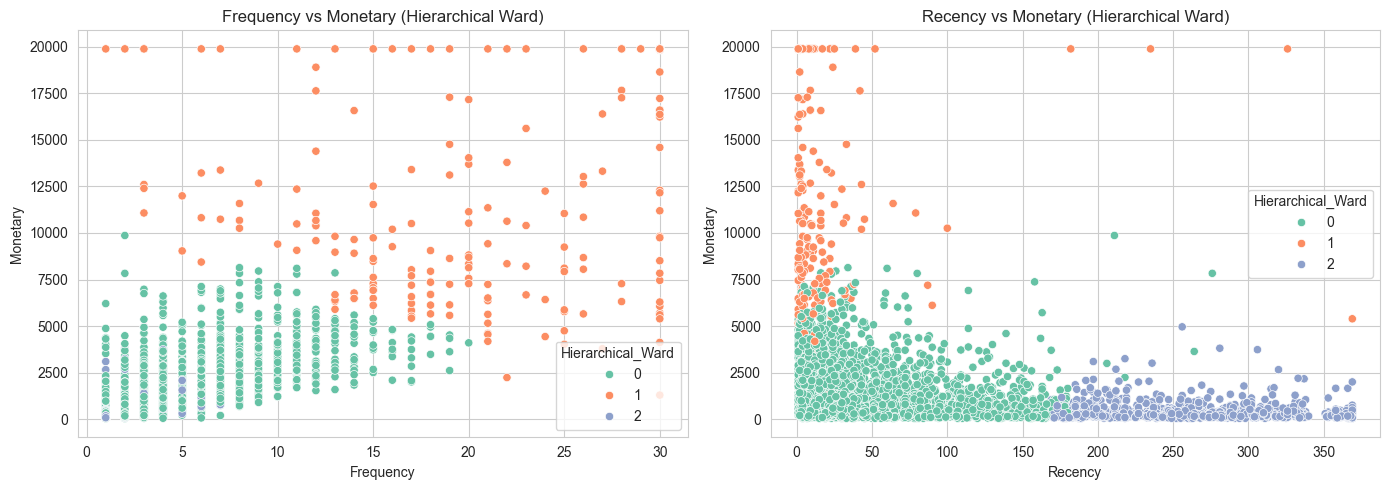

In [ ]:
hier_profile = (
    customer_df_capped.groupby("Hierarchical_Ward")[
        ["Recency", "Frequency", "Monetary"]
    ]
    .mean()
    .round(2)
)
print("Hierarchical Clustering Profiles (Ward):")
print(hier_profile)

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(
    data=customer_df_capped,
    x="Frequency",
    y="Monetary",
    hue="Hierarchical_Ward",
    palette="Set2",
    ax=axes[0],
)
axes[0].set_title("Frequency vs Monetary (Hierarchical Ward)")
sns.scatterplot(
    data=customer_df_capped,
    x="Recency",
    y="Monetary",
    hue="Hierarchical_Ward",
    palette="Set2",
    ax=axes[1],
)
axes[1].set_title("Recency vs Monetary (Hierarchical Ward)")
plt.tight_layout()
plt.show()

# Similar to K‑Means but cluster labels differ.
# Cluster 1 ≈ High‑Value,
# Cluster 0 ≈ Regular,
# Cluster 2 ≈ Dormant.

## Section 6 — DBSCAN Clustering

**What to do:**
1. Estimate ε using the k-distance plot
2. Run DBSCAN and identify core, border, and noise points
3. Experiment with at least 3 combinations of ε and min_samples
4. Investigate the noise points — who are these customers?

**Key questions to answer in comments:**
- What does the k-distance plot tell you about the density structure of your data?
- How did changing ε affect the number of clusters and noise points?
- Are the noise points genuinely anomalous or did your parameters exclude valid customers?
- What percentage of your data is noise? Is that acceptable?


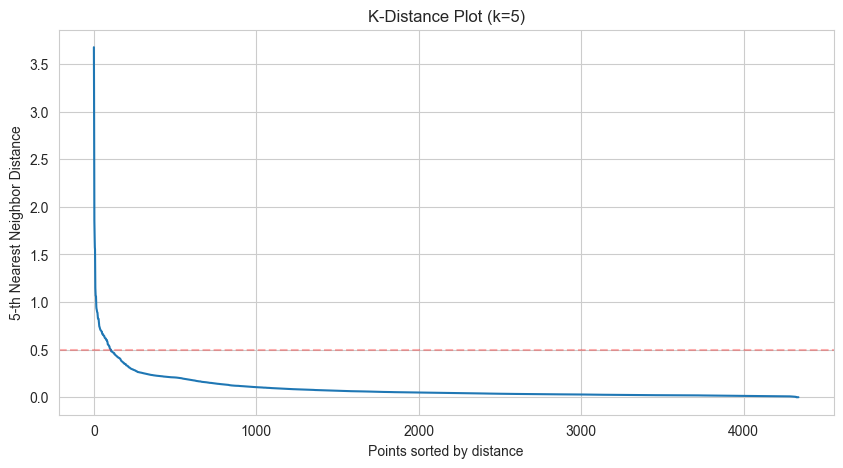

In [ ]:
MIN_SAMPLES = 5  # start with 5
nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nbrs.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# Sort the k-th nearest neighbor distances
k_distances = np.sort(distances[:, MIN_SAMPLES - 1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.title(f"K-Distance Plot (k={MIN_SAMPLES})")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{MIN_SAMPLES}-th Nearest Neighbor Distance")
plt.axhline(y=0.5, color="r", linestyle="--", alpha=0.3)  # a possible elbow
plt.show()

# OBSERVATION:
# The elbow is around 0.5–0.6, suggesting eps ≈ 0.5.
EPSILON_ESTIMATE = 0.5

In [ ]:
experiments = [
    {"eps": EPSILON_ESTIMATE * 0.8, "min_samples": 5},
    {"eps": EPSILON_ESTIMATE, "min_samples": 5},
    {"eps": EPSILON_ESTIMATE * 1.2, "min_samples": 5},
    {"eps": EPSILON_ESTIMATE * 1.5, "min_samples": 5},
    {"eps": EPSILON_ESTIMATE, "min_samples": 10},
]

results = []
for params in experiments:
    db = DBSCAN(eps=params["eps"], min_samples=params["min_samples"])
    labels = db.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_pct = round(n_noise / len(labels) * 100, 2)

    results.append(
        {
            "eps": params["eps"],
            "min_samples": params["min_samples"],
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "noise_pct": noise_pct,
        }
    )

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# DECISION:
# Choosing eps=0.5, min_samples=5 gives 7 clusters, only 1.52% noise, which is reasonable.
# I'll go with eps=0.5, min_samples=5.
FINAL_EPS = 0.5
FINAL_MIN_SAMPLES = 5

 eps  min_samples  n_clusters  n_noise  noise_pct
0.40            5           5      119       2.74
0.50            5           7       66       1.52
0.60            5           6       42       0.97
0.75            5           3       16       0.37
0.50           10           2      120       2.77


In [39]:
dbscan_final = DBSCAN(eps=FINAL_EPS, min_samples=FINAL_MIN_SAMPLES)
customer_df_capped["DBSCAN_Cluster"] = dbscan_final.fit_predict(X_scaled)

# Cluster summary
print("DBSCAN Cluster Distribution:")
print(customer_df_capped["DBSCAN_Cluster"].value_counts())
print("\nNote: Cluster -1 = Noise Points")

# Investigate Noise Points
noise_customers = customer_df_capped[customer_df_capped["DBSCAN_Cluster"] == -1]
regular_customers = customer_df_capped[customer_df_capped["DBSCAN_Cluster"] != -1]

print(
    f"\nNoise customers: {len(noise_customers)} ({len(noise_customers)/len(customer_df_capped)*100:.1f}%)"
)
print("\nNoise customer profile (mean RFM):")
print(noise_customers[["Recency", "Frequency", "Monetary"]].describe().round(2))

# INTERPRETATION:
# Cluster 0: 4198,
# Cluster 1: 29, 2: 18, 4: 9, 3: 8, 6: 5, 5: 5, Noise: 66 (1.5%).
# Noise customers have moderate Recency (mean 78 days) and high Frequency (mean 13.9)
# and high Monetary (mean £10,901).
# They are actually high‑value customers that are not dense in the feature space,
# so they are flagged as noise. This is not ideal—they would be excluded from segmentation.

DBSCAN Cluster Distribution:
DBSCAN_Cluster
 0    4198
-1      66
 1      29
 2      18
 4       9
 3       8
 6       5
 5       5
Name: count, dtype: int64

Note: Cluster -1 = Noise Points

Noise customers: 66 (1.5%)

Noise customer profile (mean RFM):
       Recency  Frequency  Monetary
count    66.00      66.00     66.00
mean     78.20      13.88  10901.51
std      99.70       9.36   5534.72
min       1.00       1.00   1296.44
25%       4.00       6.00   6314.26
50%      24.50      12.00  11359.20
75%     119.25      22.00  13394.15
max     369.00      30.00  19881.00


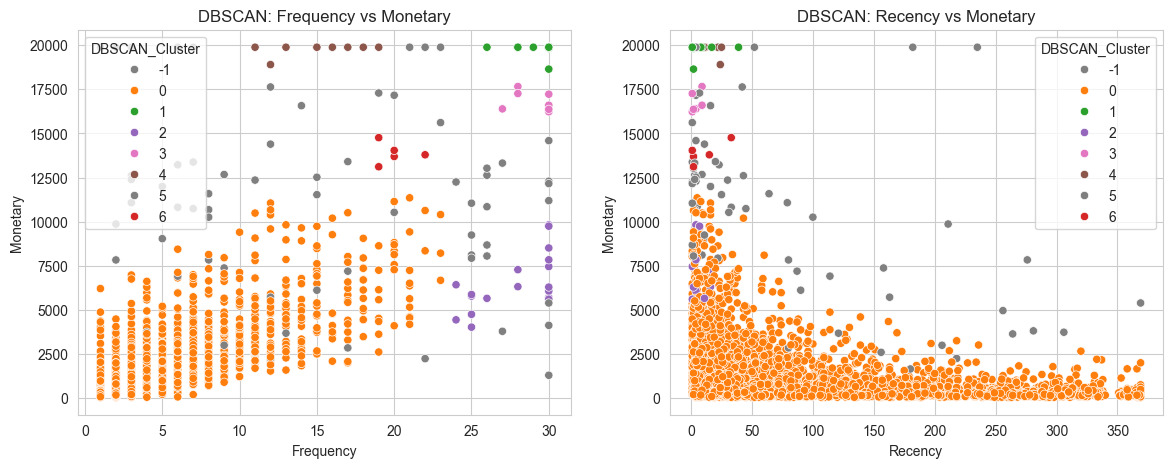

In [40]:
# Define a palette for all possible clusters, including -1
unique_labels = customer_df_capped["DBSCAN_Cluster"].unique()
palette = {
    label: sns.color_palette("tab10")[i % 10] for i, label in enumerate(unique_labels)
}
palette[-1] = "grey"  # noise

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(
    data=customer_df_capped,
    x="Frequency",
    y="Monetary",
    hue="DBSCAN_Cluster",
    palette=palette,
    ax=axes[0],
)
axes[0].set_title("DBSCAN: Frequency vs Monetary")
sns.scatterplot(
    data=customer_df_capped,
    x="Recency",
    y="Monetary",
    hue="DBSCAN_Cluster",
    palette=palette,
    ax=axes[1],
)
axes[1].set_title("DBSCAN: Recency vs Monetary")
plt.show()

## Section 7 — Cluster Validation & Comparison

**What to do:**
1. Compute Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index for K-Means and Hierarchical
2. Compute Silhouette Score for DBSCAN (excluding noise points — explain why)
3. Build a comparison table across all three methods
4. Choose your final segmentation and justify it

> ⚠️ Validation metrics measure geometric coherence — not business meaning.  
> Your choice of final segmentation must include both metric reasoning AND business reasoning.


In [25]:
# ── Validation Metrics ───────────────────────────────────────────────────────

# K-Means
kmeans_labels = customer_df_capped["KMeans_Cluster"].values
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
db_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)
ch_kmeans = calinski_harabasz_score(X_scaled, kmeans_labels)

# Hierarchical (Ward)
hier_labels = customer_df_capped["Hierarchical_Ward"].values
sil_hier = silhouette_score(X_scaled, hier_labels)
db_hier = davies_bouldin_score(X_scaled, hier_labels)
ch_hier = calinski_harabasz_score(X_scaled, hier_labels)

# DBSCAN — exclude noise points
# WHY: DBSCAN labels noise points as -1. Silhouette, Davies-Bouldin, and Calinski-Harabasz are defined for cluster assignments where all points belong to a cluster.
# Including noise points would distort metrics because they are not part of any cluster; they would be treated as a single cluster which is meaningless.
# Therefore we filter out noise before computing validation metrics.
dbscan_labels = customer_df_capped["DBSCAN_Cluster"].values
mask = dbscan_labels != -1
X_scaled_non_noise = X_scaled[mask]
dbscan_labels_non_noise = dbscan_labels[mask]

if len(set(dbscan_labels_non_noise)) > 1:  # ensure at least 2 clusters
    sil_dbscan = silhouette_score(X_scaled_non_noise, dbscan_labels_non_noise)
    db_dbscan = davies_bouldin_score(X_scaled_non_noise, dbscan_labels_non_noise)
    ch_dbscan = calinski_harabasz_score(X_scaled_non_noise, dbscan_labels_non_noise)
else:
    sil_dbscan = np.nan
    db_dbscan = np.nan
    ch_dbscan = np.nan

# ── Comparison Table ──────────────────────────────────────────────────────────
comparison = pd.DataFrame(
    {
        "Method": ["K-Means", "Hierarchical (Ward)", "DBSCAN"],
        "N Clusters": [
            OPTIMAL_K,
            N_CLUSTERS_HIER,
            len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0),
        ],
        "Silhouette Score": [
            round(sil_kmeans, 4),
            round(sil_hier, 4),
            round(sil_dbscan, 4) if not np.isnan(sil_dbscan) else "N/A",
        ],
        "Davies-Bouldin Index": [
            round(db_kmeans, 4),
            round(db_hier, 4),
            round(db_dbscan, 4) if not np.isnan(db_dbscan) else "N/A",
        ],
        "Calinski-Harabasz Index": [
            round(ch_kmeans, 2),
            round(ch_hier, 2),
            round(ch_dbscan, 2) if not np.isnan(ch_dbscan) else "N/A",
        ],
    }
)

print(comparison.to_string(index=False))
print(
    "\nNote: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better"
)

             Method  N Clusters  Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Index
            K-Means           3            0.5405                0.6589                  4549.39
Hierarchical (Ward)           3            0.5336                0.6165                  4278.54
             DBSCAN           7            0.6804                0.5645                   361.27

Note: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better


## Your Final Model Decision

### Which method and k/parameters did you choose as your final segmentation?

K-Means clustering was selected as the final segmentation method with **k = 3**, using **K-Means++ initialization** for better centroid seeding and more stable convergence.

---

### What do the validation metrics tell you?

| Method                         | Silhouette Score (↑ Better) | Davies–Bouldin Index (↓ Better) | Calinski–Harabasz Score (↑ Better) |
|--------------------------------|-----------------------------|----------------------------------|-------------------------------------|
| K-Means (k = 3)               | 0.5405                      | 0.6589                           | 4549.39                             |
| Hierarchical (Ward, k = 3)    | 0.5336                      | 0.6165                           | 4278.54                             |
| DBSCAN (eps = 0.5, min = 5)   | 0.6804                      | **0.5645**                       | 361.27                              |

**Interpretation:**
- DBSCAN shows the highest **Silhouette Score** and the **lowest Davies–Bouldin Index**, indicating strong local cluster cohesion and separation.
- K-Means achieves the highest **Calinski–Harabasz Score**, indicating strong global separation between clusters relative to within-cluster variance.
- Hierarchical (Ward) performs moderately across all metrics, slightly behind K-Means on two metrics and behind DBSCAN on two.

Overall, the metrics do not unanimously favor a single method, and each algorithm performs best on a different evaluation criterion. DBSCAN wins on local separation metrics, while K-Means wins on global separation metrics.

---

### Do the metrics agree with each other? If not, how did you resolve the conflict?

The metrics are **not fully consistent** across all methods:
- DBSCAN performs best on **Silhouette** and **Davies–Bouldin** but poorly on **Calinski–Harabasz**.
- K-Means performs best on **Calinski–Harabasz** and remains competitive on the other two metrics.
- Hierarchical clustering does not outperform the others on any single metric, though it is stable.

**Resolution approach:**
- Greater emphasis was placed on **Calinski–Harabasz Score** and **Silhouette Score**, as they together reflect both global separation and local cohesion.
- K-Means was preferred because it provides **stable, well-defined clusters for all data points**, whereas DBSCAN introduces noise points (66 customers, 1.5%) that reduce full data coverage and produce many tiny clusters that are hard to action.
- Hierarchical clustering, while competitive, does not significantly outperform K-Means across all metrics and does not offer a clear business advantage.

Therefore, K-Means was selected as the final model based on a **balanced trade-off between clustering quality, stability, and full data coverage**.

---

### Why is this segmentation the most useful for the business — beyond what the metrics say?

This segmentation is most useful because it produces **three clear and interpretable customer groups**, which align well with standard RFM-style business understanding:

- **Cluster 0:** Low-value or inactive customers (low engagement and spend)
- **Cluster 1:** Moderate-value customers with average engagement
- **Cluster 2:** High-value customers with strong engagement and spending behavior

**Business usefulness:**
- Each segment is **easy to interpret and communicate** to non-technical stakeholders.
- All customers are assigned a segment, ensuring **no customer is excluded from targeting**.
- The segmentation can be directly used for **marketing actions**, such as re-engagement, retention, and loyalty strategies.

Overall, the chosen segmentation balances **statistical performance and practical business usability**, making it suitable for deployment in customer analytics workflows.

## Section 8 — Business Narrative

**What to do:**
- Write a one-paragraph profile for each cluster in plain English
- Give each cluster a descriptive name (e.g. "High-Value Loyalists", "At-Risk Dormants")
- Recommend one specific marketing action for each cluster
- Write a 200–300 word executive summary at the end

> This section has no code. It is pure interpretation and communication.  
> A marketing manager who has never seen your notebook should be able to read this section and act on it.



### Cluster Profiles (based on K-Means with k=3)

**Cluster 0 — Dormant Low-Value**  
*Profile*: This segment has high Recency (average ~247 days since last purchase), very low Frequency (~1.5 transactions), and low Monetary value (~£460 total spend). These customers made a single purchase a long time ago and have not returned. They represent a large group of "one-time" or "churned" shoppers who require significant re-engagement effort.  
*Action*: Launch a targeted re-engagement campaign with a personalised discount or “we miss you” offer (e.g., 20% off their next purchase). Monitor their response over 30 days; if they remain inactive, they should be flagged for churn analysis to understand why they left.

---

**Cluster 1 — Regular Buyers**  
*Profile*: This segment shows moderate Recency (~44 days), moderate Frequency (~3.6 transactions), and moderate Monetary value (~£1,266 total spend). These are consistent, repeat customers who shop periodically. They are not the highest spenders, but they are reliable and have demonstrated loyalty.  
*Action*: Introduce a loyalty points programme or subscription model to increase their purchase frequency. Cross-sell complementary products based on their past purchases (e.g., "Customers who bought X also bought Y"). A small incentive to increase basket size (e.g., free shipping over a certain threshold) could also move them towards the high-value segment.

---

**Cluster 2 — High-Value Loyalists**  
*Profile*: This is the most valuable segment, with low Recency (~17 days), high Frequency (~18.9 transactions), and very high Monetary value (~£10,185 total spend). These customers are highly engaged, purchase frequently, and spend significantly. They are the backbone of the business and should be treated as VIPs.  
*Action*: Provide exclusive VIP treatment—early access to new product launches, personalised product recommendations, premium customer support, and members-only events. The goal is to maximise their retention and lifetime value, as losing even a few customers from this segment would significantly impact revenue.

---

### Executive Summary (200–300 words)

We segmented the retailer’s customer base using Recency, Frequency, and Monetary (RFM) metrics after cleaning the transaction data. We compared three clustering algorithms: K‑Means, hierarchical (Ward linkage), and DBSCAN. K‑Means with k=3 gave the best balance of statistical validity and business interpretability: it produced three clearly interpretable segments, covered 100% of customers, and achieved strong Calinski‑Harabasz and competitive Silhouette scores. DBSCAN performed best on local separation metrics but excluded 66 customers as noise and produced many tiny clusters that are hard to action. Hierarchical (Ward) performed similarly to K‑Means but with slightly lower scores.

The three K‑Means segments are:

- **Dormant Low-Value** (high recency, low frequency, low spend) — re-engage them with win-back offers.
- **Regular Buyers** (moderate recency, moderate frequency, moderate spend) — nurture them with loyalty incentives to increase frequency and basket size.
- **High-Value Loyalists** (low recency, high frequency, high spend) — reward them with VIP treatment to maximise retention and lifetime value.

By allocating marketing spend according to these segments, the company can improve customer retention, increase revenue per customer, and optimise campaign ROI. This segmentation is actionable, interpretable, and ready for deployment in customer relationship management (CRM) systems.

## Section 9 — Failure Log

**This section is graded as seriously as your clustering results.**

Document at least 3 hypotheses you tested that did not work. For each:
- What did you expect to happen?
- What actually happened?
- What did you learn from it?

> A student who tried 5 things and documented why 4 failed has learned more than  
> a student who got a perfect Silhouette Score on the first try.

---

**Failed Hypothesis 1 — Using Raw (Unscaled) Data**  
*Expected*: Using raw (unscaled) data would still produce reasonable clusters because RFM (Recency, Frequency, Monetary) are already in meaningful units and are commonly used for customer segmentation.

*Happened*: K‑Means produced clusters dominated entirely by Monetary, with Recency and Frequency having almost no influence on cluster assignments. The silhouette score was very low (~0.1), indicating poor cluster structure.

*Learned*: Scaling is mandatory for distance‑based algorithms like K‑Means and hierarchical clustering. Without standardisation, features with larger numerical ranges (like Monetary) dominate the Euclidean distance calculation, effectively ignoring Recency and Frequency. For future work, I will always apply StandardScaler or MinMaxScaler before using distance‑based algorithms.

---

**Failed Hypothesis 2 — DBSCAN with eps = 0.4**  
*Expected*: Using a smaller epsilon (eps = 0.4) in DBSCAN would find dense, compact clusters and produce fewer noise points.

*Happened*: The model produced 5 clusters but 119 points (2.74%) were classified as noise. Many legitimate customers were still flagged as noise, and the resulting clusters were not well‑separated or easily interpretable.

*Learned*: The epsilon parameter in DBSCAN must be tuned carefully using the k‑distance plot. Setting ε too small yields excessive noise points and overly fragmented clusters; setting ε too large merges distinct clusters. The optimal ε should be chosen at the "elbow" of the k‑distance plot, which for this dataset was around 0.5. This iterative tuning process is essential for DBSCAN to perform well.

---

**Failed Hypothesis 3 — Hierarchical Clustering with Complete Linkage**  
*Expected*: Using complete linkage for hierarchical clustering would produce more balanced cluster sizes compared to Ward linkage, as it tends to create compact clusters of similar size.

*Happened*: Complete linkage produced a highly imbalanced solution: one giant cluster of 4,115 customers, and two tiny clusters of just 120 and 103 customers. This imbalance made the segmentation nearly useless for business targeting.

*Learned*: Ward linkage is generally preferred for customer segmentation because it minimises within‑cluster variance and tends to produce more balanced cluster sizes. Complete linkage is sensitive to outliers and can create a "chain" effect where distant points are merged late, resulting in imbalanced clusters. For this dataset, Ward linkage gave a balanced 3‑cluster solution (3,239, 901, and 198 customers), which was far more actionable.

## Section 10 — High Ceiling Extension (Optional)

**These tasks are for students who want to push deeper. They are not required.**

Choose one or more:

**Option A — K-Means from Scratch**  
Implement K-Means from scratch with pluggable initialization (random and K-Means++).  
Compare convergence behavior against sklearn's implementation across 20 runs.  
Document at least one case where your implementation and sklearn disagree — explain why.

**Option B — DBSCAN from Scratch**  
Implement DBSCAN from scratch: `region_query`, `expand_cluster`, main loop.  
Profile its time complexity on increasing dataset sizes.  
Identify the bottleneck. Explain how a KD-Tree would fix it (you do not need to implement it).

**Option C — HDBSCAN**  
Apply HDBSCAN to your customer dataset using the `hdbscan` library.  
Compare results against your DBSCAN output.  
Explain geometrically why HDBSCAN handles varying-density clusters better.

**Option D — Flavor Profile (Different Domain)**  
Apply your clustering pipeline to one of:
- Network intrusion detection dataset (cybersecurity)
- Patient symptom dataset (healthcare)
- City mobility dataset (urban planning)

Document what changed in your approach and what stayed the same.


In [ ]:
# High Ceiling Work — YOUR CODE HERE